<a href="https://colab.research.google.com/github/Jenninekk/machine_learning_model/blob/main/Machin_learning_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Phase 1, Session 1: Healthcare Insurance Data Analysis
# Step 2 from EDA Guide: Import and Inspect the Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure pandas for better data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("🏥 Healthcare Insurance ML Project - Phase 1")
print("=" * 50)
print("Libraries imported successfully!")
print("\n What we just imported:")
print("• pandas (pd): For data manipulation and analysis")
print("• numpy (np): For numerical operations")
print("• matplotlib.pyplot (plt): For basic plotting")
print("• seaborn (sns): For statistical visualizations")

🏥 Healthcare Insurance ML Project - Phase 1
Libraries imported successfully!

 What we just imported:
• pandas (pd): For data manipulation and analysis
• numpy (np): For numerical operations
• matplotlib.pyplot (plt): For basic plotting
• seaborn (sns): For statistical visualizations


In [ ]:
# Install and use kagglehub to download the dataset
!pip install kagglehub

import kagglehub
import os

print(" Downloading healthcare insurance dataset...")

# Download the dataset
path = kagglehub.dataset_download("willianoliveiragibin/healthcare-insurance")
print(f"Dataset downloaded to: {path}")

# what files are available
print("\n Files in dataset:")
files = os.listdir(path)
for file in files:
    file_path = os.path.join(path, file)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"   {file} ({size_kb:.1f} KB)")

100%|██████████| 16.0k/16.0k [00:00<00:00, 14.7MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/willianoliveiragibin/healthcare-insurance/versions/1

 Files in dataset:
   insurance.csv (54.3 KB)


In [ ]:
# Load the main dataset
df = pd.read_csv(f'{path}/insurance.csv')

print(" INITIAL DATA INSPECTION")
print("=" * 40)

# EDA Step 2: Examine the size of the data
print(f" Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

print(f"\n Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\n Data types:")
print(df.dtypes)

 INITIAL DATA INSPECTION
 Dataset shape: 1,338 rows × 7 columns
 Memory usage: 255.2 KB

 Column names:
  1. age
  2. sex
  3. bmi
  4. children
  5. smoker
  6. region
  7. charges

 Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [ ]:
# look at first 5 rows
print("🔍 FIRST 5 ROWS OF DATA")
print("=" * 30)
display(df.head())
# laast 5 rows
print("\n🔍 LAST 5 ROWS OF DATA")
print("=" * 30)
display(df.tail())

🔍 FIRST 5 ROWS OF DATA


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



🔍 LAST 5 ROWS OF DATA


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
#  info about the dataset
print("DATASET INFO")
print("=" * 40)
df.info()

print(f"\n BASIC STATISTICAL SUMMARY")
print("=" * 40)
df.describe()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

 BASIC STATISTICAL SUMMARY


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
print(" IMMEDIATE INSIGHTS FROM THE DATA")
print("=" * 50)

# Quick categorical analysis
print(" Categorical Variables Overview:")
print(f"• Sex distribution:")
print(df['sex'].value_counts())
print(f"\n• Smoker distribution:")
print(df['smoker'].value_counts())
print(f"\n• Region distribution:")
print(df['region'].value_counts())

print(f"\n CHARGES ANALYSIS:")
print(f"• Average insurance charge: ${df['charges'].mean():,.2f}")
print(f"• Median insurance charge: ${df['charges'].median():,.2f}")
print(f"• Most expensive case: ${df['charges'].max():,.2f}")
print(f"• Least expensive case: ${df['charges'].min():,.2f}")

print(f"\n SMOKING IMPACT (Quick Look):")
smoker_charges = df.groupby('smoker')['charges'].mean()
for status, avg_charge in smoker_charges.items():
    print(f"• {status.capitalize()} smokers: ${avg_charge:,.2f} average")

smoking_difference = smoker_charges['yes'] - smoker_charges['no']
print(f"• Smokers pay ${smoking_difference:,.2f} MORE on average!")

 IMMEDIATE INSIGHTS FROM THE DATA
 Categorical Variables Overview:
• Sex distribution:
sex
male      676
female    662
Name: count, dtype: int64

• Smoker distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

• Region distribution:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

 CHARGES ANALYSIS:
• Average insurance charge: $13,270.42
• Median insurance charge: $9,382.03
• Most expensive case: $63,770.43
• Least expensive case: $1,121.87

 SMOKING IMPACT (Quick Look):
• No smokers: $8,434.27 average
• Yes smokers: $32,050.23 average
• Smokers pay $23,615.96 MORE on average!


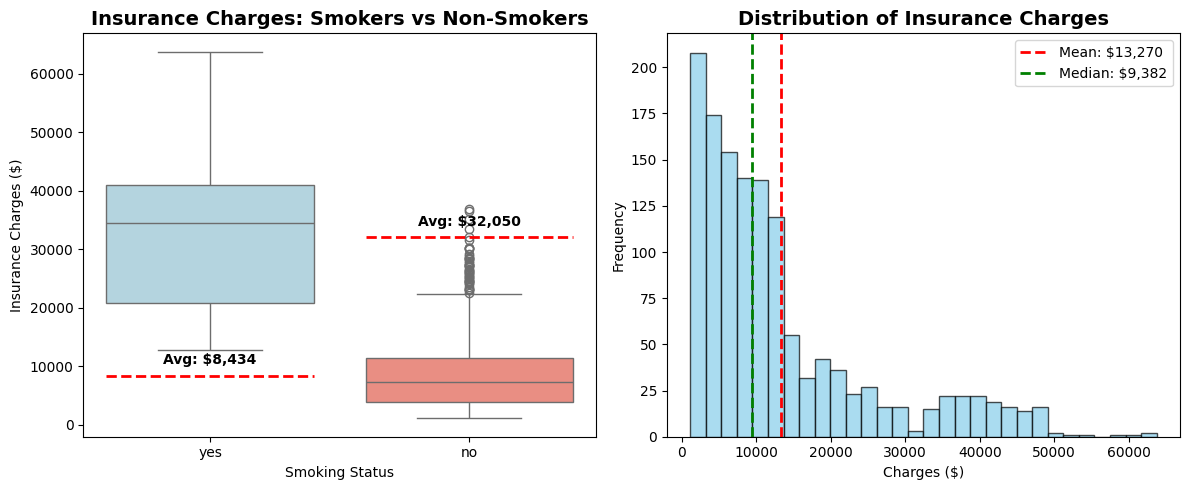

In [ ]:
# Step 6: Visualize Data Relationships
# smoking impact visually!

plt.figure(figsize=(12, 5))

# Subplot 1: Box plot of charges by smoking status
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='smoker', y='charges', palette=['lightblue', 'salmon'])
plt.title('Insurance Charges: Smokers vs Non-Smokers', fontweight='bold', fontsize=14)
plt.ylabel('Insurance Charges ($)')
plt.xlabel('Smoking Status')

# Add average lines
for i, status in enumerate(['no', 'yes']):
    avg = df[df['smoker'] == status]['charges'].mean()
    plt.hlines(avg, i-0.4, i+0.4, colors='red', linestyles='--', linewidth=2)
    plt.text(i, avg + 2000, f'Avg: ${avg:,.0f}', ha='center', fontweight='bold')

# Subplot 2: Distribution of charges
plt.subplot(1, 2, 2)
plt.hist(df['charges'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["charges"].mean():,.0f}')
plt.axvline(df['charges'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["charges"].median():,.0f}')
plt.title('Distribution of Insurance Charges', fontweight='bold', fontsize=14)
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()



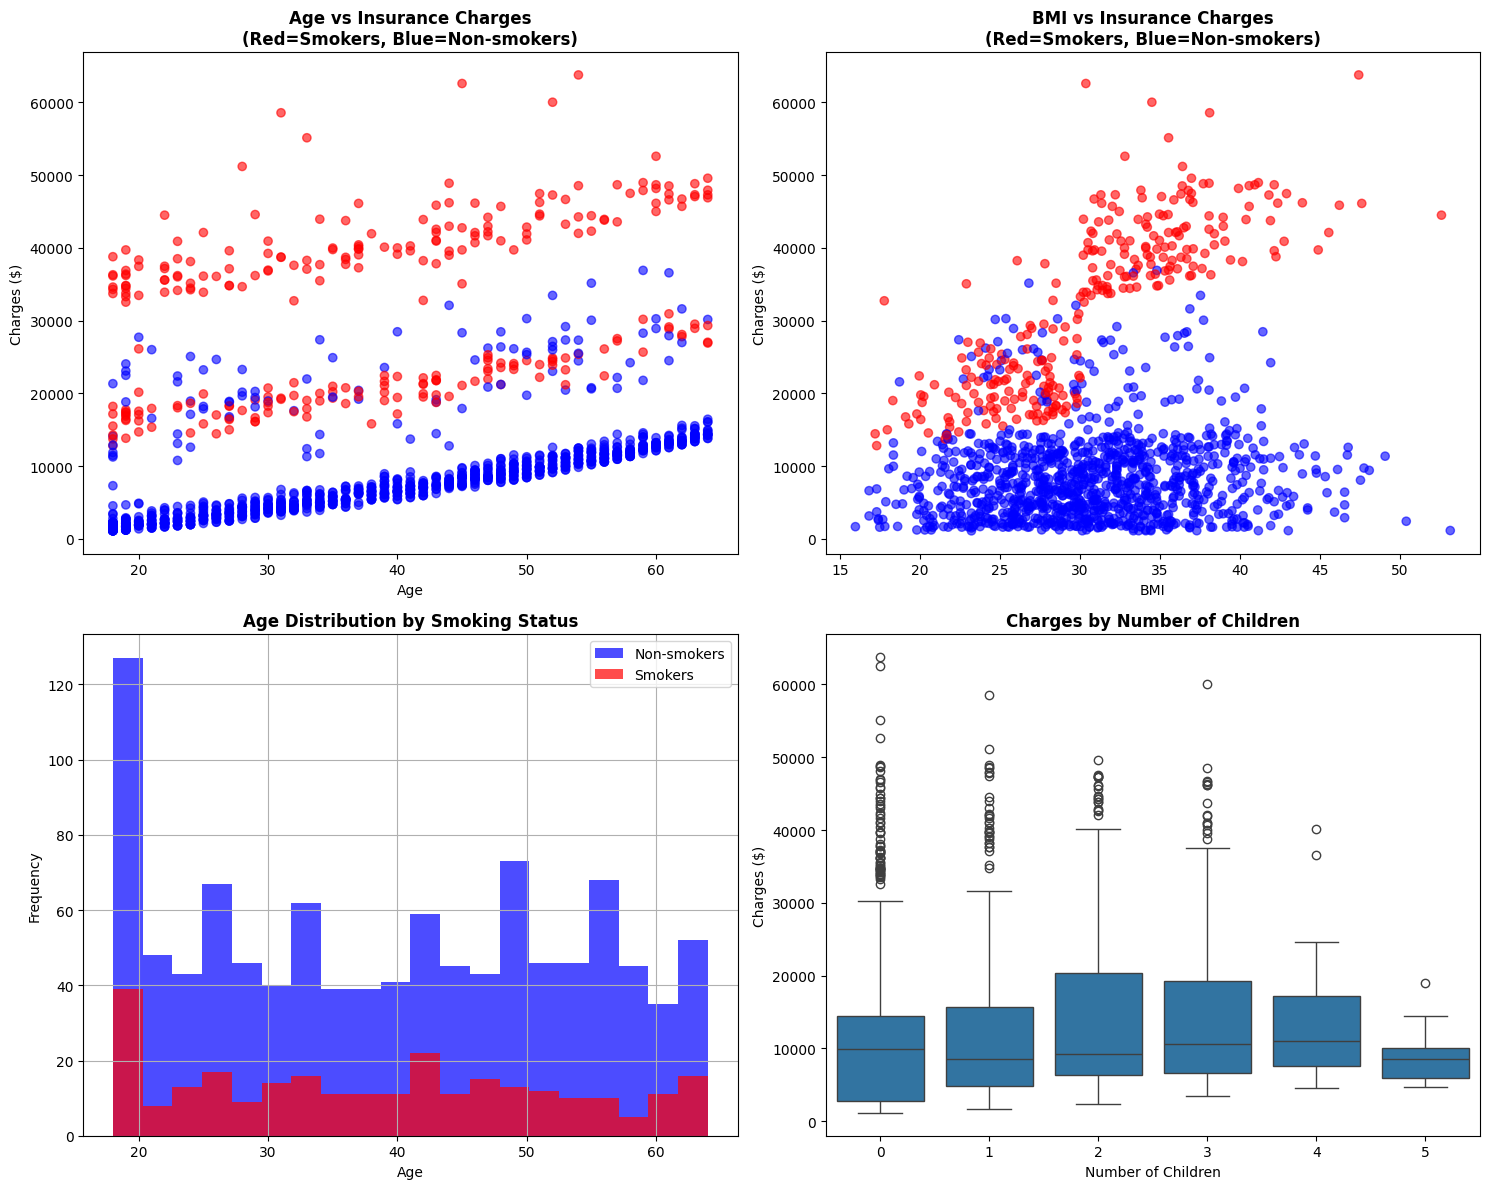

🔍 CORRELATION ANALYSIS
Correlation with charges:
• age: 0.299
• bmi: 0.198
• children: 0.068


In [ ]:
#  age and BMI relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Age vs Charges
axes[0, 0].scatter(df['age'], df['charges'], alpha=0.6, c=df['smoker'].map({'yes': 'red', 'no': 'blue'}))
axes[0, 0].set_title('Age vs Insurance Charges\n(Red=Smokers, Blue=Non-smokers)', fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Charges ($)')

# 2. BMI vs Charges
axes[0, 1].scatter(df['bmi'], df['charges'], alpha=0.6, c=df['smoker'].map({'yes': 'red', 'no': 'blue'}))
axes[0, 1].set_title('BMI vs Insurance Charges\n(Red=Smokers, Blue=Non-smokers)', fontweight='bold')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Charges ($)')

# 3. Age distribution by smoking
df[df['smoker'] == 'no']['age'].hist(bins=20, alpha=0.7, label='Non-smokers', ax=axes[1, 0], color='blue')
df[df['smoker'] == 'yes']['age'].hist(bins=20, alpha=0.7, label='Smokers', ax=axes[1, 0], color='red')
axes[1, 0].set_title('Age Distribution by Smoking Status', fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Children vs Charges
sns.boxplot(data=df, x='children', y='charges', ax=axes[1, 1])
axes[1, 1].set_title('Charges by Number of Children', fontweight='bold')
axes[1, 1].set_xlabel('Number of Children')
axes[1, 1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

# Quick correlation analysis
print("🔍 CORRELATION ANALYSIS")
print("=" * 30)
correlations = df[['age', 'bmi', 'children', 'charges']].corr()['charges'].sort_values(ascending=False)
print("Correlation with charges:")
for var, corr in correlations.items():
    if var != 'charges':
        print(f"• {var}: {corr:.3f}")

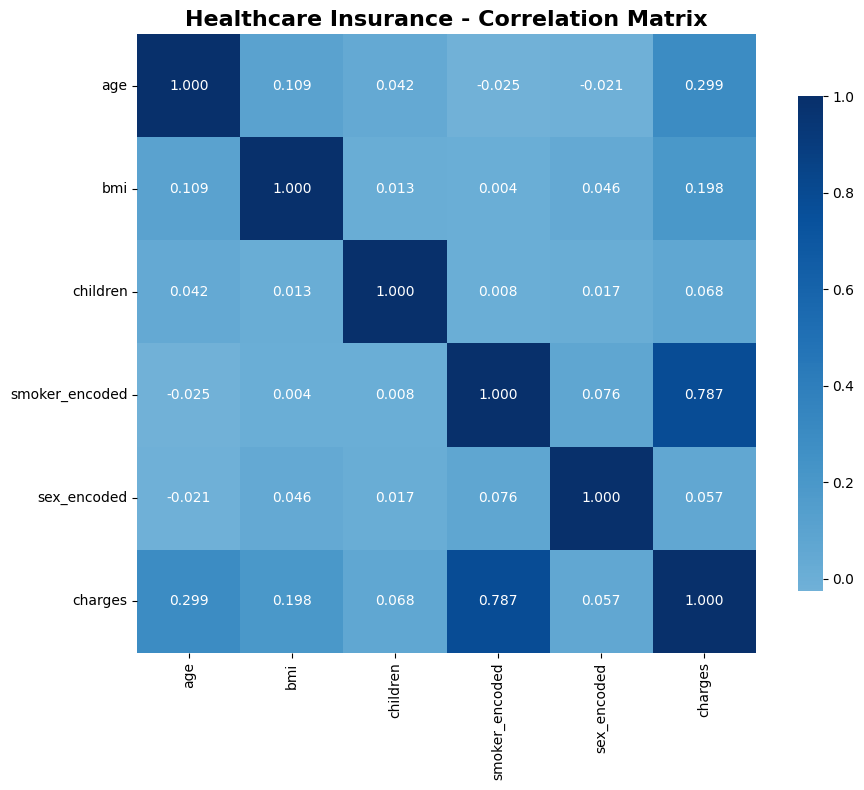

 KEY CORRELATIONS WITH CHARGES:
• charges: 1.000 (Strong Positive)
• smoker: 0.787 (Strong Positive)
• age: 0.299 (Weak Positive)
• bmi: 0.198 (Weak Positive)
• children: 0.068 (Weak Positive)


In [ ]:
# Correlation Heatmap - Blue Color Scheme
plt.figure(figsize=(10, 8))

# Prepare data for correlation (need to encode categorical variables)
df_corr = df.copy()
df_corr['smoker_encoded'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
df_corr['sex_encoded'] = df_corr['sex'].map({'female': 0, 'male': 1})

# Select only numerical columns for correlation
corr_columns = ['age', 'bmi', 'children', 'smoker_encoded', 'sex_encoded', 'charges']
correlation_matrix = df_corr[corr_columns].corr()

# Create heatmap with blue color scheme
sns.heatmap(correlation_matrix,
            annot=True,           # Show correlation values
            cmap='Blues',         # Blue color scheme
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            fmt='.3f',            # 3 decimal places
            cbar_kws={"shrink": .8})

plt.title('Healthcare Insurance - Correlation Matrix', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# Quick insights
print(" KEY CORRELATIONS WITH CHARGES:")
print("=" * 40)
charges_corr = correlation_matrix['charges'].sort_values(key=abs, ascending=False)[:-1]  # Remove self-correlation
for variable, corr_value in charges_corr.items():
    strength = "Strong" if abs(corr_value) > 0.5 else "Moderate" if abs(corr_value) > 0.3 else "Weak"
    direction = "Positive" if corr_value > 0 else "Negative"
    print(f"• {variable.replace('_encoded', '')}: {corr_value:.3f} ({strength} {direction})")

- from this findigs we can see that somkers was the most contributing factors of charges,then age.  

In [ ]:
print(" HEALTHCARE INSURANCE EDA - KEY FINDINGS SUMMARY")
print("=" * 60)

print("\n 1. SMOKING IMPACT (Correlation: 0.787)")
print("   • Smokers pay $23,616 MORE on average than non-smokers")
print("   • This represents a 280% increase in insurance costs")
print("   • Smoking is the strongest predictor of high charges")

print("\n 2. AGE EFFECT (Correlation: 0.299)")
print("   • Age shows moderate positive correlation with charges")
print("   • Older patients have higher medical costs across all groups")
print("   • Effect is stronger for smokers than non-smokers")

print("\n 3. BMI RELATIONSHIP (Correlation: 0.198)")
print("   • Weak but positive correlation with insurance charges")
print("   • Higher BMI typically leads to higher medical costs")
print("   • Impact appears more pronounced for smokers")

print("\n 4. CHILDREN FACTOR (Correlation: 0.068)")
print("   • Very weak correlation - number of children barely affects charges")
print("   • Insurance costs are primarily driven by individual health factors")
print("   • Family size has minimal impact on medical expenses")

print("\n 5. GENDER NEUTRALITY (Correlation: ~0)")
print("   • No significant difference between male and female charges")
print("   • Gender is not a meaningful predictor in this dataset")
print("   • Health behaviors (smoking) matter more than demographics")

print("\n BUSINESS IMPLICATIONS:")
print("   . Focus risk assessment on smoking status and age")
print("   . Smoking cessation programs could reduce claims significantly")
print("   . Age-based pricing is justified by data")
print("   . BMI could be considered for more precise risk modeling")
print("   . Family size can be excluded from pricing models")

📊 HEALTHCARE INSURANCE EDA - KEY FINDINGS SUMMARY

 1. SMOKING IMPACT (Correlation: 0.787)
   • Smokers pay $23,616 MORE on average than non-smokers
   • This represents a 280% increase in insurance costs
   • Smoking is the strongest predictor of high charges

 2. AGE EFFECT (Correlation: 0.299)
   • Age shows moderate positive correlation with charges
   • Older patients have higher medical costs across all groups
   • Effect is stronger for smokers than non-smokers

 3. BMI RELATIONSHIP (Correlation: 0.198)
   • Weak but positive correlation with insurance charges
   • Higher BMI typically leads to higher medical costs
   • Impact appears more pronounced for smokers

 4. CHILDREN FACTOR (Correlation: 0.068)
   • Very weak correlation - number of children barely affects charges
   • Insurance costs are primarily driven by individual health factors
   • Family size has minimal impact on medical expenses

 5. GENDER NEUTRALITY (Correlation: ~0)
   • No significant difference between ma

### Feature Engineering Setup

In [ ]:
# Phase 2: Feature Engineering for Machine Learning
print(" FEATURE ENGINEERING & ML PREPARATION")
print("=" * 50)

# Create a copy for feature engineering
df_model = df.copy()

# 1. Encode categorical variables for ML
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_model['sex_encoded'] = le_sex.fit_transform(df_model['sex'])
df_model['smoker_encoded'] = le_smoker.fit_transform(df_model['smoker'])
df_model['region_encoded'] = le_region.fit_transform(df_model['region'])

# 2. Create new features based on our EDA insights
df_model['age_squared'] = df_model['age'] ** 2  # Non-linear age effect
df_model['bmi_squared'] = df_model['bmi'] ** 2  # Non-linear BMI effect
df_model['smoker_age'] = df_model['smoker_encoded'] * df_model['age']  # Smoking + age interaction
df_model['smoker_bmi'] = df_model['smoker_encoded'] * df_model['bmi']  # Smoking + BMI interaction

# 3. Create BMI categories as features
df_model['is_obese'] = (df_model['bmi'] >= 30).astype(int)
df_model['is_overweight'] = ((df_model['bmi'] >= 25) & (df_model['bmi'] < 30)).astype(int)

print(f"Original features: {df.shape[1]}")
print(f"Enhanced features: {df_model.shape[1]}")

# Show the new features we created
new_features = ['age_squared', 'bmi_squared', 'smoker_age', 'smoker_bmi', 'is_obese', 'is_overweight']
print(f"New features created: {new_features}")

# Quick preview of engineered features
print(f"\n Sample of engineered features:")
display(df_model[['age', 'smoker_encoded', 'smoker_age', 'bmi', 'is_obese', 'charges']].head())

 FEATURE ENGINEERING & ML PREPARATION
 Feature engineering completed!
Original features: 7
Enhanced features: 16
New features created: ['age_squared', 'bmi_squared', 'smoker_age', 'smoker_bmi', 'is_obese', 'is_overweight']

 Sample of engineered features:


,age,smoker_encoded,smoker_age,bmi,is_obese,charges
0,19,1,19,27.900,0,16884.92400
1,18,0,0,33.770,1,1725.55230
2,28,0,0,33.000,1,4449.46200
3,33,0,0,22.705,0,21984.47061
4,32,0,0,28.880,0,3866.85520


In [ ]:
# Prepare features and target
print(" PREPARING DATA FOR MACHINE LEARNING")
print("=" * 45)

# Select features for modeling
feature_columns = ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded',
                  'region_encoded', 'age_squared', 'bmi_squared', 'smoker_age',
                  'smoker_bmi', 'is_obese', 'is_overweight']

X = df_model[feature_columns]
y = df_model['charges']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Quick preview
print(f"\n Feature preview:")
print(X_train.head())

 PREPARING DATA FOR MACHINE LEARNING
Features (X): (1338, 12)
Target (y): (1338,)
Training set: 1070 samples
Testing set: 268 samples

 Feature preview:
      age    bmi  children  sex_encoded  smoker_encoded  region_encoded  \
560    46  19.95         2            0               0               1   
1285   47  24.32         0            0               0               0   
1142   52  24.86         0            0               0               2   
969    39  34.32         5            0               0               2   
486    54  21.47         3            0               0               1   

      age_squared  bmi_squared  smoker_age  smoker_bmi  is_obese  \
560          2116     398.0025           0         0.0         0   
1285         2209     591.4624           0         0.0         0   
1142         2704     618.0196           0         0.0         0   
969          1521    1177.8624           0         0.0         1   
486          2916     460.9609           0         0.0  

In [ ]:
# Train models based on your modeling approach
print(" TRAINING MACHINE LEARNING MODELS")
print("=" * 45)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize models
models = {
    'Linear Regression': LinearRegression(),  # Baseline interpretable model
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),  # Capture nonlinear relationships
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)  # Handle complex patterns
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\n Training {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    results[name] = {
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        'Model': model
    }

    print(f"    R² Score: {r2:.4f}")
    print(f"    RMSE: ${rmse:,.0f}")
    print(f"    MAE: ${mae:,.0f}")

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['R² Score'])
print(f"\n BEST MODEL: {best_model_name}")
print(f"   R² Score: {results[best_model_name]['R² Score']:.4f}")
print(f"   RMSE: ${results[best_model_name]['RMSE']:,.0f}")

# Model interpretation
print(f"\n MODEL ANALYSIS:")
print(f"   • Linear Regression: Interpretable baseline for continuous outcomes")
print(f"   • Random Forest: Captures nonlinear relationships and feature interactions")
print(f"   • Gradient Boosting: Handles complex patterns in insurance data")

 TRAINING MACHINE LEARNING MODELS

 Training Linear Regression...
    R² Score: 0.8693
    RMSE: $4,504
    MAE: $2,702

 Training Random Forest...
    R² Score: 0.8636
    RMSE: $4,601
    MAE: $2,521

 Training Gradient Boosting...
    R² Score: 0.8786
    RMSE: $4,341
    MAE: $2,439

 BEST MODEL: Gradient Boosting
   R² Score: 0.8786
   RMSE: $4,341

 MODEL ANALYSIS:
   • Linear Regression: Interpretable baseline for continuous outcomes
   • Random Forest: Captures nonlinear relationships and feature interactions
   • Gradient Boosting: Handles complex patterns in insurance data
